In [19]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from scipy.stats import levy_stable
from torch.utils.data import DataLoader, TensorDataset

In [102]:
# 1. SETUP & DATA LOADING
# Using A9a dataset (Binary Classification)
# You can download 'a9a' from LIBSVM website or use a local path
def get_data():
    # For a quick start, let's generate a synthetic sharp dataset if a9a isn't local
    # But for your project, replace this with: load_svmlight_file('a9a.txt')
    # x = torch.randn(2000, 123) 
    # y = torch.randint(0, 2, (2000,)).float()
    # X_train, y_train = load_svmlight_file("a9a")
    # X_test, y_test = load_svmlight_file("a9a.t")

    X_train, y_train = load_svmlight_file("a9a.txt", n_features=123)
    X_test, y_test = load_svmlight_file("a9a.t", n_features=123)

    # Convert to Dense Tensors
    X_train = torch.from_numpy(X_train.toarray()).float()
    y_train = torch.from_numpy(y_train).float()
    X_test = torch.from_numpy(X_test.toarray()).float()
    y_test = torch.from_numpy(y_test).float()

    # Crucial: a9a labels are -1 and 1. Change to 0 and 1 for BCE Loss.
    y_train[y_train == -1] = 0
    y_test[y_test == -1] = 0

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = get_data()


In [103]:
# 2. DEFINING THE MODEL & NON-CONVEX LOSS
class NonConvexLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(NonConvexLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)
        
    def forward(self, x):
        return self.linear(x).squeeze()

def non_convex_regularizer(model, lam=0.1, alpha=1.0):
    reg = 0
    for param in model.parameters():
        # Geman-McClure: sum( (lam * w^2) / (1 + alpha * w^2) )
        reg += torch.sum((lam * param**2) / (1 + alpha * param**2))
    return reg



In [104]:
# 3. NOISE GENERATION (Lévy / Heavy-Tailed)
def add_heavy_tailed_noise(grad, alpha_levy=1.5, scale=0.01):
    """
    alpha_levy: 2.0 is Gaussian, 1.0 is Cauchy (Heavier).
    The paper suggests alpha < 2 captures the 'spikes'.
    """
    noise = levy_stable.rvs(alpha_levy, 0, scale=scale, size=grad.shape)
    return grad + torch.from_numpy(noise).float()



In [131]:
a9a_dataset = TensorDataset(X_train, y_train)
a9a_train_loader = DataLoader(a9a_dataset, batch_size=1024, shuffle=True)

In [106]:
# # 4. TRAINING LOOP
# def run_experiment(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
#     model = NonConvexLogisticRegression(123)
#     criterion = nn.BCEWithLogitsLoss()
#     losses = []
    
#     for epoch in range(epochs):
#         # Full batch gradient for stability control, then add synthetic noise
#         outputs = model(X_train)

#         #regularizer
#         loss_val = criterion(outputs, y_train) + non_convex_regularizer(model)

#         #without regularizer
#         # loss_val = criterion(outputs, y_train)
    
        
#         model.zero_grad()
#         loss_val.backward()
        
#         with torch.no_grad():
#             for param in model.parameters():
#                 # Inject Heavy-Tailed Noise into the gradient
#                 noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                
#                 if opt_type == 'sgd':
#                     param -= lr * noisy_grad
#                 elif opt_type == 'signsgd':
#                     # DSignSGD Step: sign(grad + noise)
#                     param -= lr * torch.sign(noisy_grad)
        
#         losses.append(loss_val.item())
#     return losses, model



In [107]:

def calculate_accuracy(outputs, targets):
    # Get the index of the max logit along the class dimension (dim=1)
    # predictions = torch.argmax(outputs, dim=1)
    predictions = (outputs > 0).long()
    correct = (predictions == targets).sum().item()
    return (correct / len(targets)) * 100.0

In [132]:
#4. TRAINING LOOP minibatch
def run_experiment(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
    model = NonConvexLogisticRegression(123)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    accs = []
    grad_norms = []
    
    for epoch in range(epochs):

        epoch_loss = 0.0
        for X_batch, y_batch in a9a_train_loader:
            # Full batch gradient for stability control, then add synthetic noise - changed to batch
            outputs = model(X_batch)

            #regularizer
            loss_val = criterion(outputs, y_batch) + non_convex_regularizer(model)

            #without regularizer
            # loss_val = criterion(outputs, y_train)
        
            
            model.zero_grad()
            loss_val.backward()

            #-- grad sq. norm --#
            total_norm_sq = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    # Sum up the squared elements of the gradient vector
                    total_norm_sq += torch.sum(param.grad ** 2).item()
            
            # This is the ||∇f(w_t)||^2 for this iteration
            grad_norms.append(total_norm_sq)

            # -- . -- #

            
            with torch.no_grad():
                for param in model.parameters():
                    # Inject Heavy-Tailed Noise into the gradient
                    noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                    
                    if opt_type == 'sgd':
                        param -= lr * noisy_grad
                    elif opt_type == 'signsgd':
                        # DSignSGD Step: sign(grad + noise)
                        param -= lr * torch.sign(noisy_grad)
            epoch_loss += loss_val.item()

        # losses.append(loss_val.item())
        # Record the average loss across all mini-batches for this epoch
        losses.append(epoch_loss / len(a9a_train_loader))

        with torch.no_grad():
            test_outputs = model(X_test)
            test_acc = calculate_accuracy(test_outputs, y_test)
            accs.append(test_acc)
            print(f"Test Accuracy ({opt_type}) epoch {epoch}: {test_acc:.2f}%")
        
    return losses, accs, grad_norms, model

In [51]:
def run_experiment_decay_lr(opt_type='sgd', alpha_levy=1.5, lr=0.01, epochs=100):
    model = NonConvexLogisticRegression(123)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    accs = []
    grad_norms = []

    initial_lr = lr;
    
    for epoch in range(epochs):

        current_lr = initial_lr / np.sqrt(epoch + 1)

        epoch_loss = 0.0
        for X_batch, y_batch in a9a_train_loader:
            # Full batch gradient for stability control, then add synthetic noise - changed to batch
            outputs = model(X_batch)

            #regularizer
            loss_val = criterion(outputs, y_batch) + non_convex_regularizer(model)

            #without regularizer
            # loss_val = criterion(outputs, y_train)
        
            
            model.zero_grad()
            loss_val.backward()

            #-- grad sq. norm --#
            total_norm_sq = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    # Sum up the squared elements of the gradient vector
                    total_norm_sq += torch.sum(param.grad ** 2).item()
            
            # This is the ||∇f(w_t)||^2 for this iteration
            grad_norms.append(total_norm_sq)

            # -- . -- #

            
            with torch.no_grad():
                for param in model.parameters():
                    # Inject Heavy-Tailed Noise into the gradient
                    noisy_grad = add_heavy_tailed_noise(param.grad, alpha_levy)
                    
                    if opt_type == 'sgd':
                        param -= current_lr * noisy_grad
                    elif opt_type == 'signsgd':
                        # DSignSGD Step: sign(grad + noise)
                        param -= current_lr * torch.sign(noisy_grad)
            epoch_loss += loss_val.item()

        # losses.append(loss_val.item())
        # Record the average loss across all mini-batches for this epoch
        losses.append(epoch_loss / len(a9a_train_loader))

        with torch.no_grad():
            test_outputs = model(X_test)
            test_acc = calculate_accuracy(test_outputs, y_test)
            accs.append(test_acc)
            print(f"Test Accuracy ({opt_type}) epoch {epoch}: {test_acc:.2f}%")
        
    return losses, accs, grad_norms, model

In [ ]:
# 5. RUNNING THE COMPARISON - decay lr

# alpha = 2, lr = 0.01
print("Running Experiments...")
history_sgd, history_acc_sgd, grad_norms_sgd, model_sgd = run_experiment_decay_lr(opt_type='sgd', alpha_levy=1.2, lr=0.01, epochs=50)
history_signsgd, history_acc_signsgd, grad_norms_signsgd, model_signsgd = run_experiment_decay_lr(opt_type='signsgd', alpha_levy=1.2, lr=0.01, epochs=50)


Running Experiments...
Test Accuracy (sgd) epoch 0: 76.41%
Test Accuracy (sgd) epoch 1: 76.40%
Test Accuracy (sgd) epoch 2: 76.40%
Test Accuracy (sgd) epoch 3: 76.42%
Test Accuracy (sgd) epoch 4: 76.44%
Test Accuracy (sgd) epoch 5: 76.45%
Test Accuracy (sgd) epoch 6: 76.51%
Test Accuracy (sgd) epoch 7: 76.55%
Test Accuracy (sgd) epoch 8: 76.64%
Test Accuracy (sgd) epoch 9: 76.71%
Test Accuracy (sgd) epoch 10: 76.80%
Test Accuracy (sgd) epoch 11: 76.86%
Test Accuracy (sgd) epoch 12: 76.89%
Test Accuracy (sgd) epoch 13: 77.02%
Test Accuracy (sgd) epoch 14: 77.05%
Test Accuracy (sgd) epoch 15: 77.14%
Test Accuracy (sgd) epoch 16: 77.19%
Test Accuracy (sgd) epoch 17: 77.21%
Test Accuracy (sgd) epoch 18: 77.27%
Test Accuracy (sgd) epoch 19: 77.32%
Test Accuracy (sgd) epoch 20: 77.35%
Test Accuracy (sgd) epoch 21: 77.41%
Test Accuracy (sgd) epoch 22: 77.47%
Test Accuracy (sgd) epoch 23: 77.55%
Test Accuracy (sgd) epoch 24: 77.58%
Test Accuracy (sgd) epoch 25: 77.61%
Test Accuracy (sgd) epoch

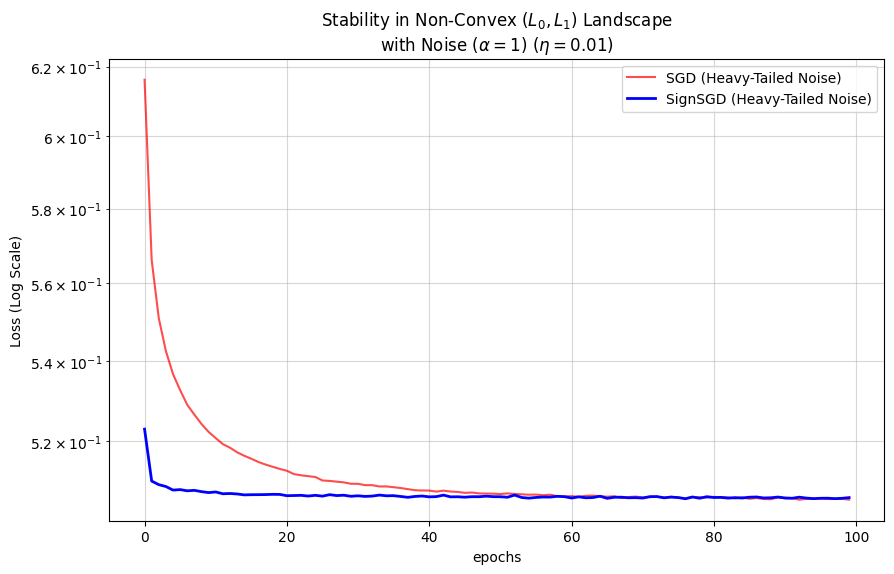

In [56]:
# 6. PLOTTING RESULTS
plt.figure(figsize=(10, 6))
plt.plot(history_sgd, label='SGD (Heavy-Tailed Noise)', color='red', alpha=0.7)
plt.plot(history_signsgd, label='SignSGD (Heavy-Tailed Noise)', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('epochs')
plt.ylabel('Loss (Log Scale)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Noise ($\\alpha=1$) ($\\eta=0.01$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [109]:
# plot acc and loss

import matplotlib.pyplot as plt

def plot_training_results(sgd_loss, sgd_acc, signsgd_loss, signsgd_acc, alpha_levy, batch_size):
    epochs = range(1, len(sgd_loss) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Left Plot: Loss per Epoch
    plt.subplot(1, 2, 1)
    plt.plot(epochs, sgd_loss, color='crimson', marker='o', label='SGD Loss')
    plt.plot(epochs, signsgd_loss, color='teal', marker='^', label='SignSGD Loss')
    plt.title(f'Training Loss per Epoch, (Noise ($\\alpha={alpha_levy}$)) (Batch Size {batch_size})', fontsize=12)
    # print(f"Test Accuracy ({opt_type}) epoch {epoch}: {test_acc:.2f}%")
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.grid(alpha=0.3)
    plt.legend()
    
    # Right Plot: Accuracy per Epoch
    plt.subplot(1, 2, 2)
    plt.plot(epochs, sgd_acc, color='crimson', marker='o', linestyle='--', label='SGD Accuracy')
    plt.plot(epochs, signsgd_acc, color='teal', marker='^', linestyle='--', label='SignSGD Accuracy')
    plt.title(f'Test Accuracy per Epoch, (Noise ($\\alpha={alpha_levy}$)) (Batch Size {batch_size})', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

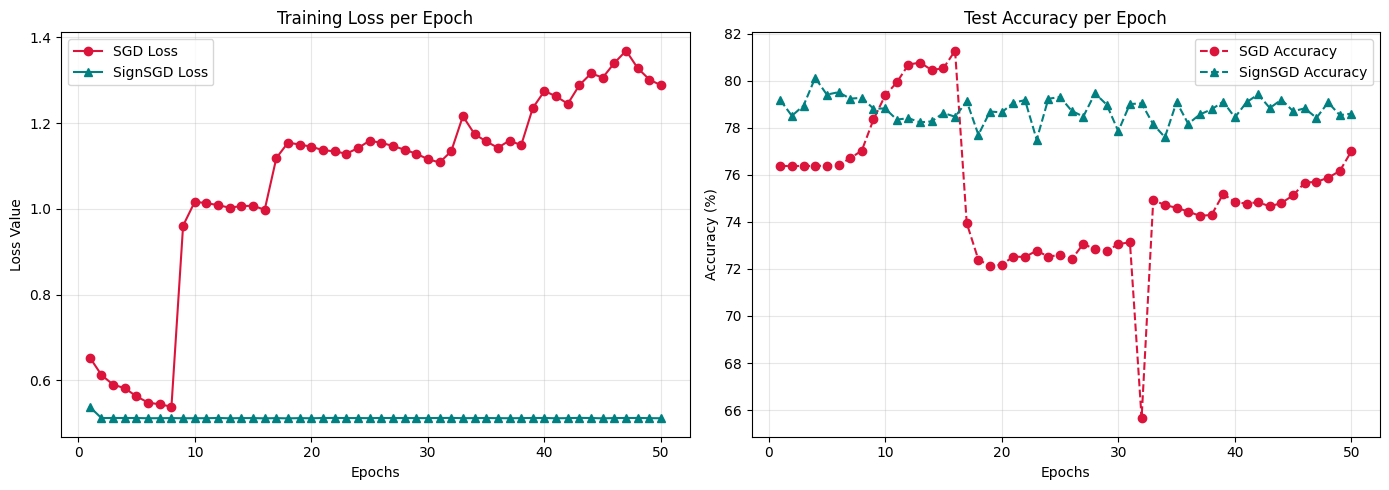

In [61]:
plot_training_results(history_sgd, history_acc_sgd, history_signsgd, history_acc_signsgd)

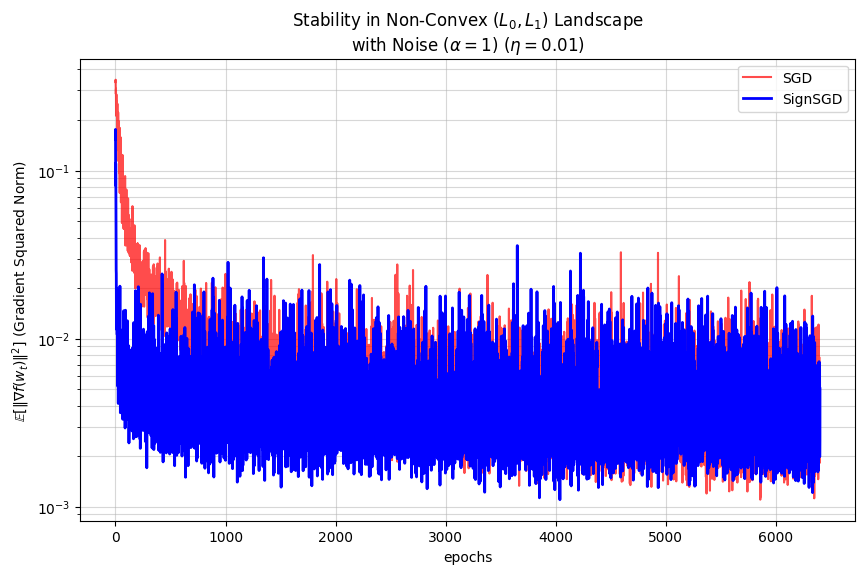

In [ ]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_sgd, label='SGD', color='red', alpha=0.7)
plt.plot(grad_norms_signsgd, label='SignSGD', color='blue', lw=2)
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Stability in Non-Convex $(L_0, L_1)$ Landscape\nwith Noise ($\\alpha=1$) ($\\eta=0.01$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_1d_landscape(model, X, y, optimal_weights, lam=0.1):

    # 1. SAVE the real weights so we don't break the model
    original_state = {name: param.clone() for name, param in model.named_parameters()}
    
    start_weights = torch.randn_like(optimal_weights) * 0.5
    alphas = np.linspace(-0.5, 1.5, 50) 
    losses = []

    # # 1. Create a random starting direction
    # start_weights = torch.randn_like(optimal_weights) * 0.5
    
    # # 2. Create the linear path (alphas)
    # alphas = np.linspace(-0.5, 1.5, 50) 
    # losses = []

    # print("Mapping the landscape... please wait.")
    
    for a in alphas:
        # Interpolate between random point and trained optimal point
        # W_current = (1-a)*W_start + a*W_optimal
        current_w = (1 - a) * start_weights + a * optimal_weights
        
        with torch.no_grad():
            # Overwrite temporarily to calculate loss
            for name, param in model.named_parameters():
                param.copy_(current_w)
            
            out = model(X)
            loss = torch.nn.BCEWithLogitsLoss()(out, y) + non_convex_regularizer(model, lam=lam)
            losses.append(loss.item())

        # Load these weights into the model
        # with torch.no_grad():
        #     state_dict = model.state_dict()
        #     for name, param in model.named_parameters():
        #         state_dict[name].copy_(current_w)
            
        #     # Forward pass
        #     out = model(X)
        #     # Loss = Data Loss + Non-Convex Regularizer
        #     loss = torch.nn.BCEWithLogitsLoss()(out, y) + non_convex_regularizer(model, lam=lam)
        #     losses.append(loss.item())

    with torch.no_grad():
        for name, param in model.named_parameters():
            param.copy_(original_state[name])
    
    # 3. Actually Plot it
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, losses, color='teal', lw=2)
    plt.axvline(x=1.0, color='red', linestyle='--', label='Trained Weights')
    plt.axvline(x=0.0, color='gray', linestyle='--', label='Random Start')
    
    plt.title("A Slice of the Landscape")
    plt.xlabel("Step along the path (Alpha)")
    plt.ylabel("Total Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show() # <--- This makes the plot appear!

# To run it, make sure you have 'model' and 'X_train', 'y_train' defined
# and that 'optimal_weights' is model.linear.weight.data (or similar)

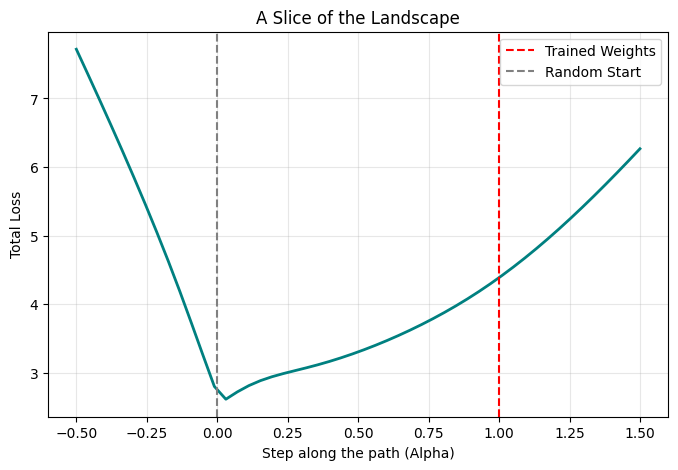

In [46]:
opt_w = list(model_sgd.parameters())[0].data.clone()
plot_1d_landscape(model_sgd, X_train, y_train, opt_w, lam=0.1)

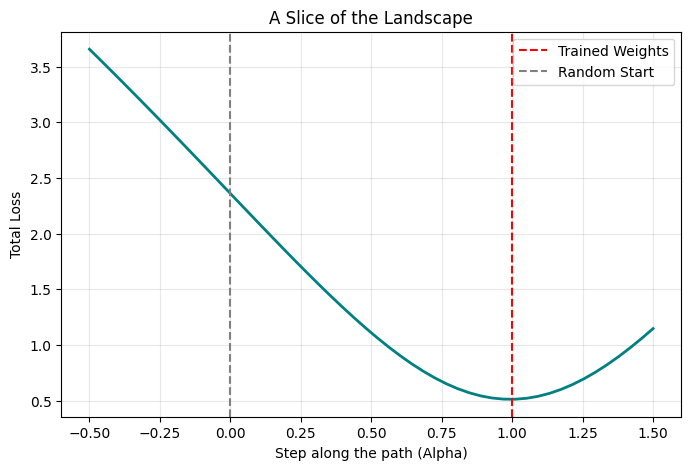

In [47]:
opt_w = list(model_signsgd.parameters())[0].data.clone()
plot_1d_landscape(model_signsgd, X_train, y_train, opt_w, lam=0.1)

In [133]:
# 5. RUNNING THE COMPARISON

# alpha = 2, lr = 0.01
print("Running Experiments...")
history_sgd_2, history_acc_sgd_2, grad_norms_sgd_2, model_sgd_2 = run_experiment(opt_type='sgd', alpha_levy=2, lr=0.01, epochs=50)
history_signsgd_2, history_acc_signsgd_2, grad_norms_signsgd_2, model_signsgd_2 = run_experiment(opt_type='signsgd', alpha_levy=2, lr=0.01, epochs=50)


Running Experiments...
Test Accuracy (sgd) epoch 0: 76.54%
Test Accuracy (sgd) epoch 1: 76.41%
Test Accuracy (sgd) epoch 2: 76.39%
Test Accuracy (sgd) epoch 3: 76.40%
Test Accuracy (sgd) epoch 4: 76.41%
Test Accuracy (sgd) epoch 5: 76.43%
Test Accuracy (sgd) epoch 6: 76.44%
Test Accuracy (sgd) epoch 7: 76.49%
Test Accuracy (sgd) epoch 8: 76.59%
Test Accuracy (sgd) epoch 9: 76.70%
Test Accuracy (sgd) epoch 10: 76.90%
Test Accuracy (sgd) epoch 11: 77.00%
Test Accuracy (sgd) epoch 12: 77.13%
Test Accuracy (sgd) epoch 13: 77.27%
Test Accuracy (sgd) epoch 14: 77.40%
Test Accuracy (sgd) epoch 15: 77.49%
Test Accuracy (sgd) epoch 16: 77.59%
Test Accuracy (sgd) epoch 17: 77.75%
Test Accuracy (sgd) epoch 18: 77.87%
Test Accuracy (sgd) epoch 19: 77.93%
Test Accuracy (sgd) epoch 20: 77.96%
Test Accuracy (sgd) epoch 21: 78.02%
Test Accuracy (sgd) epoch 22: 78.08%
Test Accuracy (sgd) epoch 23: 78.14%
Test Accuracy (sgd) epoch 24: 78.22%
Test Accuracy (sgd) epoch 25: 78.28%
Test Accuracy (sgd) epoch

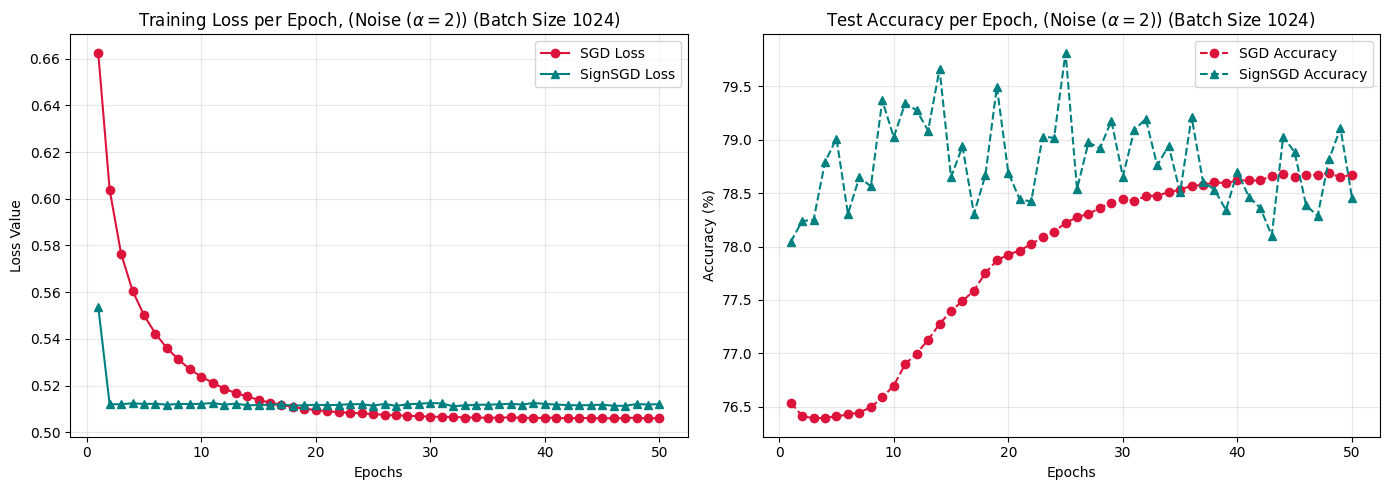

In [134]:
plot_training_results(history_sgd_2, history_acc_sgd_2, history_signsgd_2, history_acc_signsgd_2, 2, 1024)

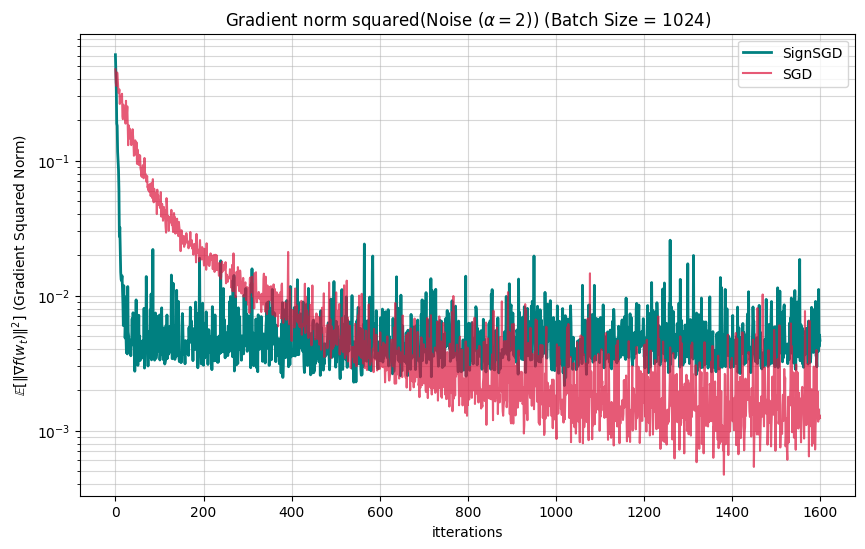

In [135]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_2, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_2, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={2}$)) (Batch Size = 1024)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [136]:
# 5. RUNNING THE COMPARISON

# alpha = 1.4, lr = 0.01
print("Running Experiments...")
history_sgd_1_4, history_acc_sgd_1_4, grad_norms_sgd_1_4, model_sgd_1_4 = run_experiment(opt_type='sgd', alpha_levy=1.4, lr=0.01, epochs=50)
history_signsgd_1_4, history_acc_signsgd_1_4, grad_norms_signsgd_1_4, model_signsgd_1_4 = run_experiment(opt_type='signsgd', alpha_levy=1.4, lr=0.01, epochs=50)


Running Experiments...
Test Accuracy (sgd) epoch 0: 76.20%
Test Accuracy (sgd) epoch 1: 76.37%
Test Accuracy (sgd) epoch 2: 76.38%
Test Accuracy (sgd) epoch 3: 76.40%
Test Accuracy (sgd) epoch 4: 76.40%
Test Accuracy (sgd) epoch 5: 76.41%
Test Accuracy (sgd) epoch 6: 76.42%
Test Accuracy (sgd) epoch 7: 76.43%
Test Accuracy (sgd) epoch 8: 76.44%
Test Accuracy (sgd) epoch 9: 76.50%
Test Accuracy (sgd) epoch 10: 76.61%
Test Accuracy (sgd) epoch 11: 76.78%
Test Accuracy (sgd) epoch 12: 76.84%
Test Accuracy (sgd) epoch 13: 77.00%
Test Accuracy (sgd) epoch 14: 77.16%
Test Accuracy (sgd) epoch 15: 77.08%
Test Accuracy (sgd) epoch 16: 77.32%
Test Accuracy (sgd) epoch 17: 77.33%
Test Accuracy (sgd) epoch 18: 77.51%
Test Accuracy (sgd) epoch 19: 77.62%
Test Accuracy (sgd) epoch 20: 77.77%
Test Accuracy (sgd) epoch 21: 77.76%
Test Accuracy (sgd) epoch 22: 77.96%
Test Accuracy (sgd) epoch 23: 78.03%
Test Accuracy (sgd) epoch 24: 78.18%
Test Accuracy (sgd) epoch 25: 78.18%
Test Accuracy (sgd) epoch

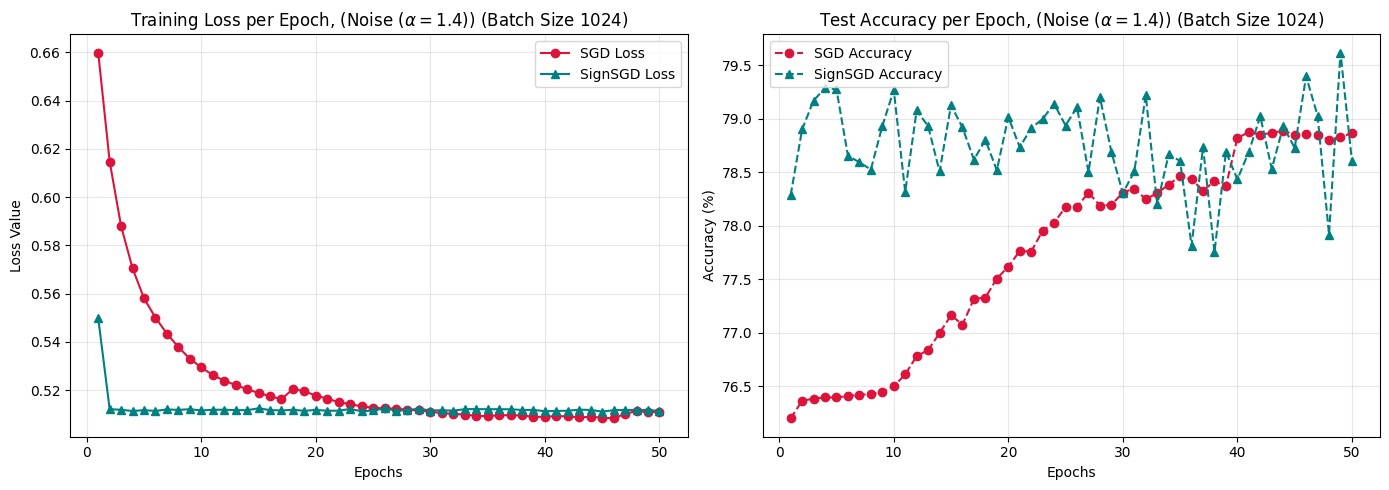

In [137]:
plot_training_results(history_sgd_1_4, history_acc_sgd_1_4, history_signsgd_1_4, history_acc_signsgd_1_4, 1.4, 1024)

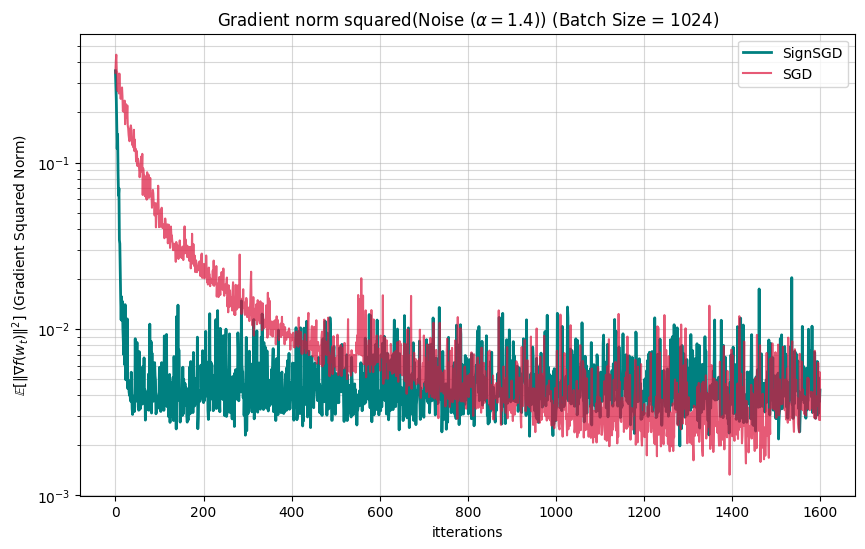

In [138]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_1_4, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_1_4, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={1.4}$)) (Batch Size = 1024)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [139]:
# 5. RUNNING THE COMPARISON

# alpha = 1, lr = 0.01
print("Running Experiments...")
history_sgd_1, history_acc_sgd_1, grad_norms_sgd_1, model_sgd_1 = run_experiment(opt_type='sgd', alpha_levy=1, lr=0.01, epochs=50)
history_signsgd_1, history_acc_signsgd_1, grad_norms_signsgd_1, model_signsgd_1 = run_experiment(opt_type='signsgd', alpha_levy=1, lr=0.01, epochs=50)


Running Experiments...
Test Accuracy (sgd) epoch 0: 77.74%
Test Accuracy (sgd) epoch 1: 76.57%
Test Accuracy (sgd) epoch 2: 76.55%
Test Accuracy (sgd) epoch 3: 76.48%
Test Accuracy (sgd) epoch 4: 76.49%
Test Accuracy (sgd) epoch 5: 76.56%
Test Accuracy (sgd) epoch 6: 76.68%
Test Accuracy (sgd) epoch 7: 76.87%
Test Accuracy (sgd) epoch 8: 76.74%
Test Accuracy (sgd) epoch 9: 77.96%
Test Accuracy (sgd) epoch 10: 77.89%
Test Accuracy (sgd) epoch 11: 77.78%
Test Accuracy (sgd) epoch 12: 77.81%
Test Accuracy (sgd) epoch 13: 76.09%
Test Accuracy (sgd) epoch 14: 76.05%
Test Accuracy (sgd) epoch 15: 75.79%
Test Accuracy (sgd) epoch 16: 75.54%
Test Accuracy (sgd) epoch 17: 75.52%
Test Accuracy (sgd) epoch 18: 75.51%
Test Accuracy (sgd) epoch 19: 75.56%
Test Accuracy (sgd) epoch 20: 75.50%
Test Accuracy (sgd) epoch 21: 75.54%
Test Accuracy (sgd) epoch 22: 75.51%
Test Accuracy (sgd) epoch 23: 75.52%
Test Accuracy (sgd) epoch 24: 75.54%
Test Accuracy (sgd) epoch 25: 75.59%
Test Accuracy (sgd) epoch

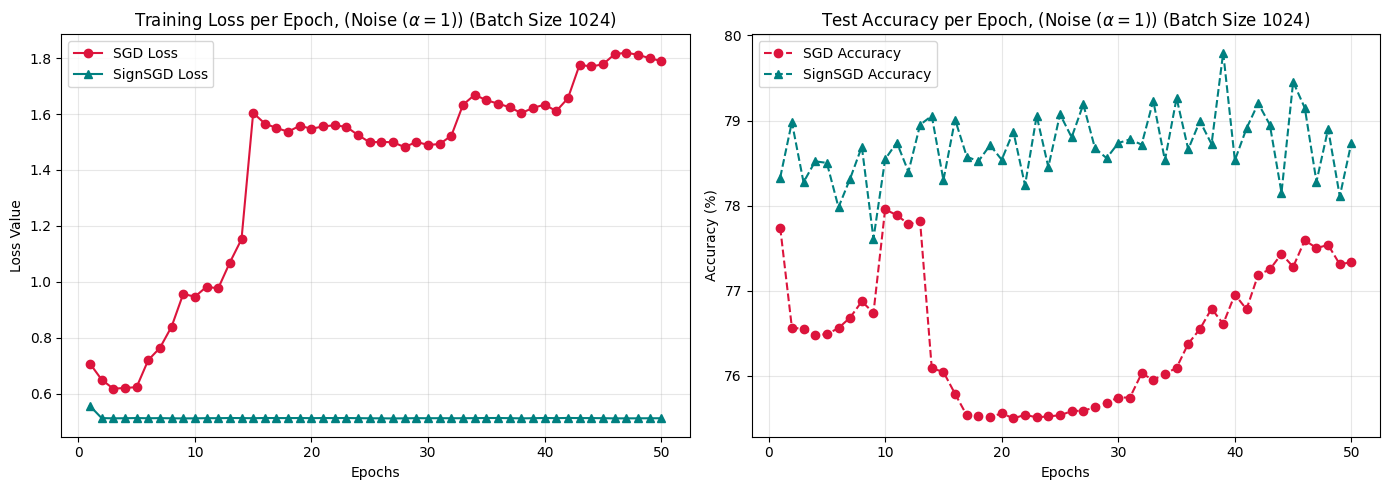

In [140]:
plot_training_results(history_sgd_1, history_acc_sgd_1, history_signsgd_1, history_acc_signsgd_1, 1, 1024)

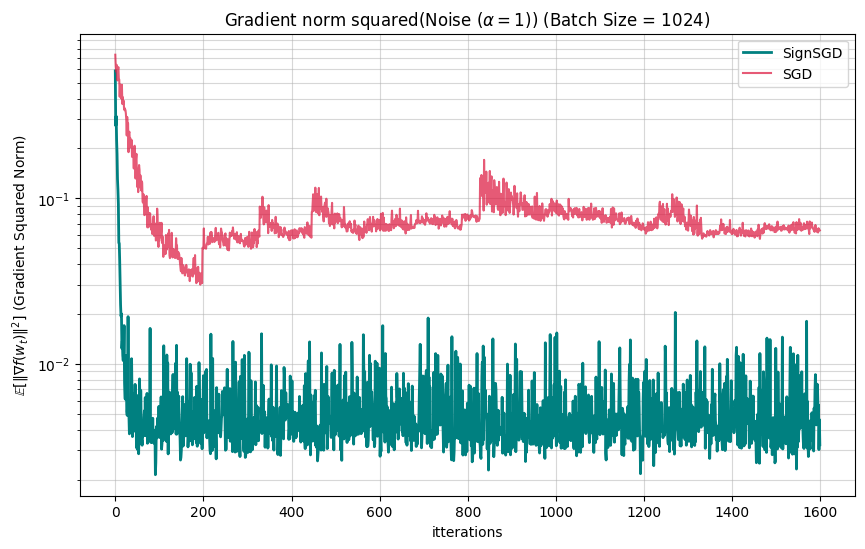

In [141]:
# PLOTTING grad norm
plt.figure(figsize=(10, 6))
plt.plot(grad_norms_signsgd_1, label='SignSGD', color='teal', lw=2)
plt.plot(grad_norms_sgd_1, label='SGD', color='crimson', alpha=0.7)
# plt.plot(grad_norms_signsgd, label='SignSGD', color='teal', lw=2)
plt.yscale('log')
plt.xlabel('itterations')
plt.ylabel(r'$\mathbb{E}[\|\nabla f(w_t)\|^2]$ (Gradient Squared Norm)')
plt.title('Gradient norm squared(Noise ($\\alpha={1}$)) (Batch Size = 1024)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()